# IG-RDT Metrics Report

Renders Tables 1/2/3 and Figs A/B/C from the full-pass JSONL outputs.

**Inputs expected in `data/`:**
- `metrics_{task}_{model}_seed{seed}_*.jsonl` — per-step rows (one per policy call) + `episode_end` rows. From `per_step_ig.py`.
- `metrics_faithfulness_*.jsonl` — B1/B2 rows. From `faithfulness.py`.
- `metrics_sanity_C1_*.jsonl`, `metrics_sanity_C2_*.jsonl` — Spearman ρ rows. From `sanity.py`.

**Overlays for Fig B** are expected in `out/overlays/<task>/ep*.png`.

**Run locally** after rsync'ing JSONLs + `out/` back from the pod. Sidecars (∼150 GB total) are not needed here.

In [1]:
import glob
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = '../data'
OUT_DIR  = '../out'

#Tag rows with the m used to produce them, derived from the source filename.
#Files matching '_m{X}.jsonl' are m=X; otherwise default m=64 (the production setup).
_M_RE = re.compile(r'_m(\d+)\.jsonl$')

def load_jsonl(pattern):
    rows = []
    for path in sorted(glob.glob(os.path.join(DATA_DIR, pattern))):
        m_match = _M_RE.search(os.path.basename(path))
        m = int(m_match.group(1)) if m_match else 64
        with open(path) as f:
            for line in f:
                try:
                    r = json.loads(line)
                except json.JSONDecodeError:
                    continue
                r['__m'] = m
                rows.append(r)
    return rows

step_rows       = [r for r in load_jsonl('metrics_*_seed*.jsonl') if r.get('event') == 'step']
episode_rows    = [r for r in load_jsonl('metrics_*_seed*.jsonl') if r.get('event') == 'episode_end']
faithfulness_rows = load_jsonl('metrics_faithfulness_*.jsonl')
sanity_c1_rows    = load_jsonl('metrics_sanity_C1_*.jsonl')
sanity_c2_rows    = load_jsonl('metrics_sanity_C2*.jsonl')

#m breakdown across step rows
m_counts = pd.Series([r['__m'] for r in step_rows]).value_counts().to_dict() if step_rows else {}
print(f'steps: {len(step_rows)} (m breakdown: {m_counts}) | episode-end: {len(episode_rows)} | faithfulness: {len(faithfulness_rows)} | sanity C1: {len(sanity_c1_rows)} | sanity C2: {len(sanity_c2_rows)}')

steps: 3048 (m breakdown: {64: 2248, 128: 800}) | episode-end: 452 | faithfulness: 2694 | sanity C1: 400 | sanity C2: 400


## Table 1 — Correctness (O1)

Median completeness error per (task, modality) and percent of calls meeting the `≤3%` threshold. Threshold: median ≤3% on ≥90% of cases.

Note: noise-dominated calls (ε-small F-gap) inflate the ratio. We report the full set, a `|ref|≥15` signal-bearing subset, and the threshold-pass rate on the signal-bearing subset.

In [2]:
df = pd.DataFrame(step_rows)
if len(df) == 0:
    print('no step rows yet; run the full pass (scripts/run_full_pass.sh) and rsync data/ back.')
else:
    def err_summary(d):
        return pd.Series({
            'n': len(d),
            'vision_median': d['vision_err'].median(),
            'lang_median':   d['lang_err'].median(),
            'state_median':  d['state_err'].median(),
            'vision_pct_leq_3%': (d['vision_err'] <= 0.03).mean() * 100,
            'lang_pct_leq_3%':   (d['lang_err']   <= 0.03).mean() * 100,
            'state_pct_leq_3%':  (d['state_err']  <= 0.03).mean() * 100,
        })
    for m in sorted(df['__m'].unique()):
        sub = df[df['__m'] == m]
        print(f'=== m={m} ===')
        table_all = sub.groupby(['task','model']).apply(err_summary)
        table_signal = sub[sub['ref_norm_maniskill'] >= 15].groupby(['task','model']).apply(err_summary)
        print('All calls:'); print(table_all)
        print('\nSignal-bearing (|ref|>=15):'); print(table_signal); print()

=== m=64 ===
All calls:
                               n  vision_median  lang_median  state_median  \
task                model                                                    
PegInsertionSide-v1 170m   700.0       0.025104     0.018680      0.038726   
PickCube-v1         170m   397.0       0.022254     0.021184      0.065269   
                    1b     354.0       0.018916     0.025313      0.009823   
PickSingleYCB-v1    170m   397.0       0.020471     0.021315      0.045338   
StackCube-v1        170m   400.0       0.024611     0.019630      0.090693   

                           vision_pct_leq_3%  lang_pct_leq_3%  \
task                model                                       
PegInsertionSide-v1 170m           64.000000        72.000000   
PickCube-v1         170m           62.468514        64.231738   
                    1b             80.790960        58.192090   
PickSingleYCB-v1    170m           69.521411        65.491184   
StackCube-v1        170m           61.7

## Fig A — Completeness histograms per task

One panel per task, three histograms (vision / language / state) overlaid. x-axis clipped to `[0, 0.5]` so noise-dominated outliers don't compress the distribution.

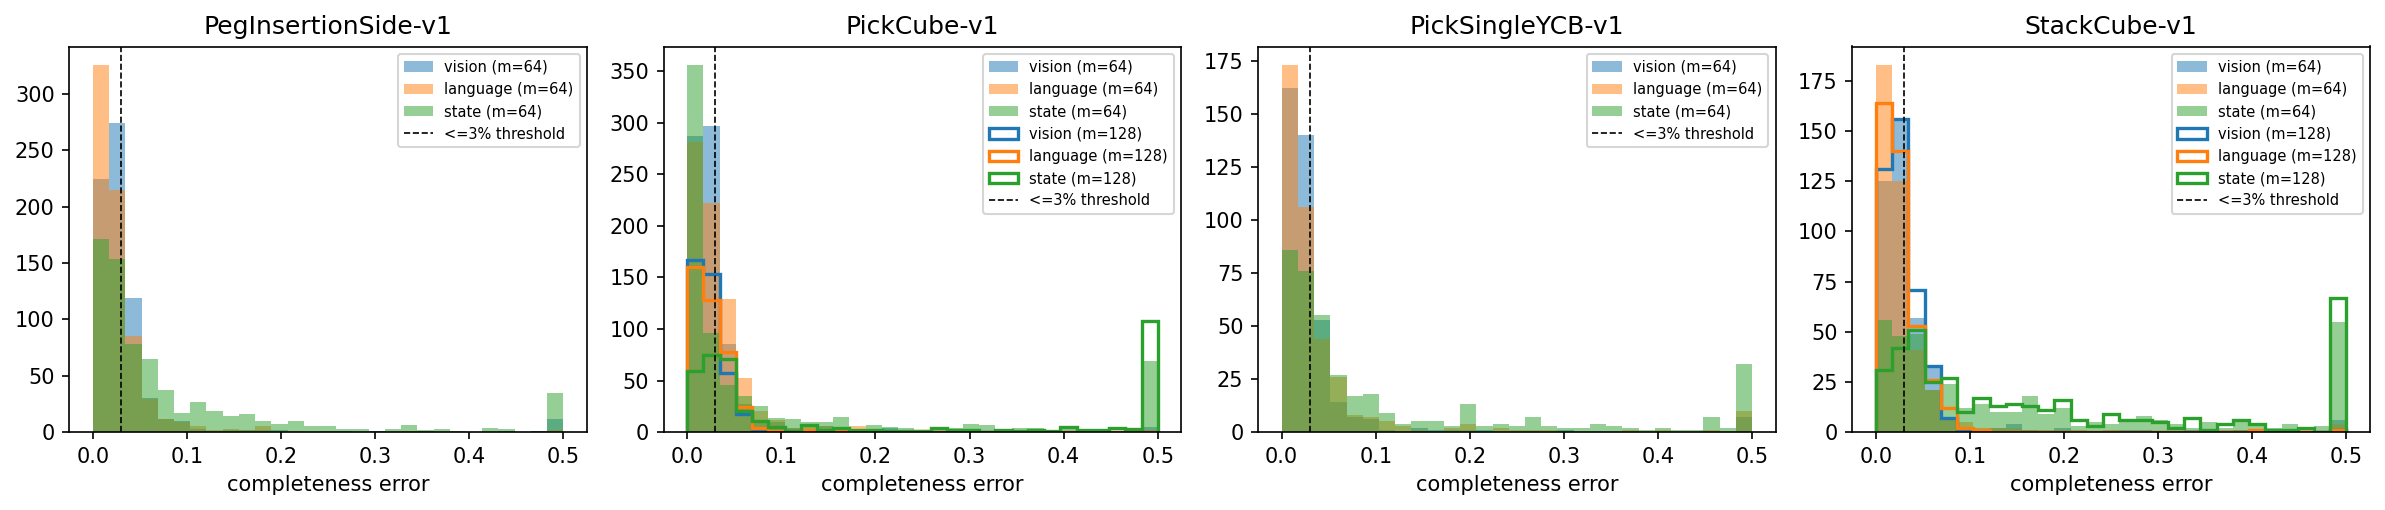

In [3]:
if len(df) > 0:
    tasks = sorted(df['task'].unique())
    fig, axes = plt.subplots(1, len(tasks), figsize=(4*len(tasks), 3.5), dpi=150)
    if len(tasks) == 1: axes = [axes]
    bins = np.linspace(0, 0.5, 30)
    for ax, task in zip(axes, tasks):
        d64  = df[(df['task']==task) & (df['__m']==64)]
        d128 = df[(df['task']==task) & (df['__m']==128)]
        ax.hist(d64['vision_err'].clip(upper=0.5), bins=bins, alpha=0.5, label='vision (m=64)')
        ax.hist(d64['lang_err'].clip(upper=0.5),   bins=bins, alpha=0.5, label='language (m=64)')
        ax.hist(d64['state_err'].clip(upper=0.5),  bins=bins, alpha=0.5, label='state (m=64)')
        if len(d128) > 0:
            ax.hist(d128['vision_err'].clip(upper=0.5), bins=bins, histtype='step', linewidth=1.6, color='C0', label='vision (m=128)')
            ax.hist(d128['lang_err'].clip(upper=0.5),   bins=bins, histtype='step', linewidth=1.6, color='C1', label='language (m=128)')
            ax.hist(d128['state_err'].clip(upper=0.5),  bins=bins, histtype='step', linewidth=1.6, color='C2', label='state (m=128)')
        ax.axvline(0.03, color='k', ls='--', lw=0.8, label='<=3% threshold')
        ax.set_title(task)
        ax.set_xlabel('completeness error')
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig('../out/figures/fig_a_completeness.png', dpi=300, bbox_inches='tight')
    plt.show()

## Table 2 — Faithfulness (O2)

Median Δlog p at k=5% and Insertion/Deletion AUC per (task, modality). Thresholds: image Δlog p ≤ -0.5 nats, Insertion ≥ 0.60, Deletion ≤ 0.40; tokens Δlog p ≤ -0.5, Insertion ≥ 0.55, Deletion ≤ 0.45.

In [4]:
fdf = pd.DataFrame(faithfulness_rows)
if len(fdf) == 0:
    print('no faithfulness rows yet; run scripts/run_faithfulness.sh.')
else:
    def faith_summary(d):
        return pd.Series({
            'n': len(d),
            'v_dlogp_k5_median': d['vision_dlogp_k5'].median(),
            'v_insertion_auc':    d['vision_insertion_auc'].median(),
            'v_deletion_auc':     d['vision_deletion_auc'].median(),
            'l_dlogp_k5_median':  d['lang_dlogp_k5'].median(),
            'l_insertion_auc':    d['lang_insertion_auc'].median(),
            'l_deletion_auc':     d['lang_deletion_auc'].median(),
        })
    for m in sorted(fdf['__m'].unique()):
        sub = fdf[fdf['__m'] == m]
        print(f'=== m={m} ===')
        print(sub.groupby(['task','model']).apply(faith_summary)); print()

=== m=64 ===
                               n  v_dlogp_k5_median  v_insertion_auc  \
task                model                                              
PegInsertionSide-v1 170m   700.0          -0.001329         0.762056   
PickCube-v1         170m   797.0          -0.002176         0.823847   
PickSingleYCB-v1    170m   397.0          -0.001503         0.823976   
StackCube-v1        170m   800.0          -0.001934         0.854032   

                           v_deletion_auc  l_dlogp_k5_median  l_insertion_auc  \
task                model                                                       
PegInsertionSide-v1 170m         0.304386          -0.002292         0.373634   
PickCube-v1         170m         0.326019          -0.000252         0.599654   
PickSingleYCB-v1    170m         0.323906          -0.000311         0.366240   
StackCube-v1        170m         0.345715          -0.001560         0.435800   

                           l_deletion_auc  
task                mod

## Fig C — Insertion / Deletion curves

Median-of-medians curve per modality, aggregated across tasks and seeds. The y-axis is the normalized log π (0=baseline, 1=input).

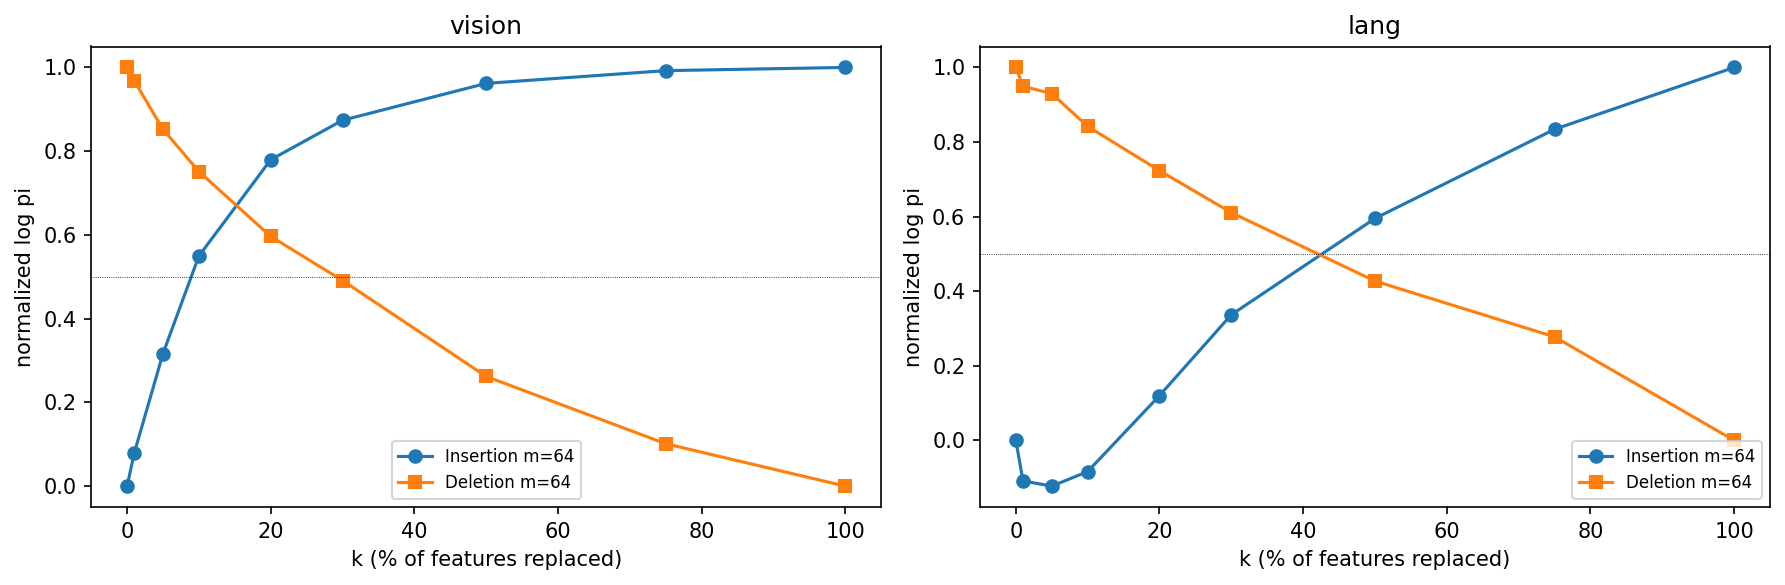

In [5]:
if len(fdf) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)
    for ax, modality in zip(axes, ['vision', 'lang']):
        for m, ls, alpha in [(64, '-', 1.0), (128, '--', 1.0)]:
            sub = fdf[fdf['__m'] == m]
            if len(sub) == 0:
                continue
            ins = np.vstack([r for r in sub[f'{modality}_insertion_curve']])
            dele = np.vstack([r for r in sub[f'{modality}_deletion_curve']])
            k = sub['k_grid_auc'].iloc[0]
            fi = sub[f'{modality}_f_input'].values[:, None]
            fb = sub[f'{modality}_f_baseline'].values[:, None]
            denom = fi - fb
            ins_n  = (ins  - fb) / np.where(np.abs(denom) < 1e-9, 1.0, denom)
            dele_n = (dele - fb) / np.where(np.abs(denom) < 1e-9, 1.0, denom)
            ax.plot(k, np.nanmedian(ins_n,  axis=0), 'o' + ls, alpha=alpha, label=f'Insertion m={m}')
            ax.plot(k, np.nanmedian(dele_n, axis=0), 's' + ls, alpha=alpha, label=f'Deletion m={m}')
        ax.set_title(f'{modality}')
        ax.set_xlabel('k (% of features replaced)'); ax.set_ylabel('normalized log pi')
        ax.axhline(0.5, color='k', lw=0.4, ls=':')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('../out/figures/fig_c_auc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

## Table 3 — Sanity (O3)

Spearman ρ under model re-init (C1) and input randomization (C2). Threshold: ρ ≤ 0.2 means attribution did NOT survive the perturbation (desired outcome).

In [6]:
c1 = pd.DataFrame(sanity_c1_rows); c2 = pd.DataFrame(sanity_c2_rows)
if len(c1) == 0 and len(c2) == 0:
    print('no sanity rows yet; run scripts/run_sanity.sh.')
else:
    def rho_summary(d):
        return pd.Series({
            'n': len(d),
            'vision_rho_median': d['spearman_vision'].median(),
            'lang_rho_median':   d['spearman_language'].median(),
            'state_rho_median':  d['spearman_state'].median(),
        })
    if len(c1) > 0:
        print('C1 (model re-init):')
        print(c1.groupby(['task','model']).apply(rho_summary))
    if len(c2) > 0:
        print('\nC2 (input shuffle):')
        print(c2.groupby(['task','model']).apply(rho_summary))

C1 (model re-init):
                               n  vision_rho_median  lang_rho_median  \
task                model                                              
PegInsertionSide-v1 170m   100.0           0.960567         0.952005   
PickCube-v1         170m   100.0           0.943680         0.905398   
PickSingleYCB-v1    170m   100.0           0.929819         0.915716   
StackCube-v1        170m   100.0           0.958893         0.967841   

                           state_rho_median  
task                model                    
PegInsertionSide-v1 170m           0.761905  
PickCube-v1         170m           0.726190  
PickSingleYCB-v1    170m           0.726190  
StackCube-v1        170m           0.642857  

C2 (input shuffle):
                               n  vision_rho_median  lang_rho_median  \
task                model                                              
PegInsertionSide-v1 170m   100.0           0.086380         0.010772   
PickCube-v1         170m   100.0  

## Fig B — Example overlays

Grid of 2 successes + 2 failures across two tasks. Picks episodes from the `episode_end` rows. Requires `out/overlays/<task>/ep*_t*.png` generated by `generate_overlays.py`.

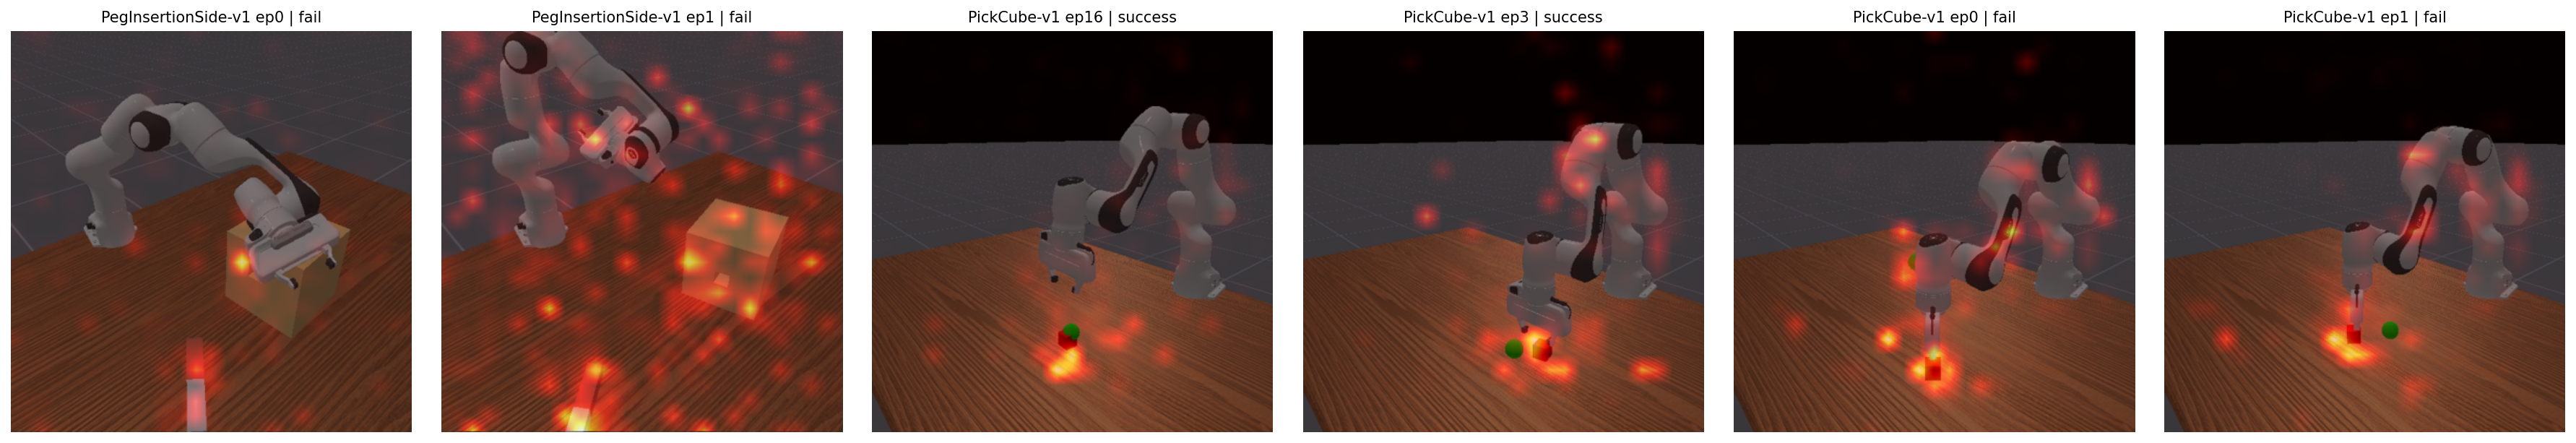

In [7]:
ep_df = pd.DataFrame(episode_rows)
if len(ep_df) == 0 or not os.path.isdir(os.path.join(OUT_DIR, 'overlays')):
    print('no episodes or no overlays yet; run scripts/run_overlays.sh.')
else:
    #pick first 2 successes and first 2 failures from up to two tasks
    picked = []
    for task in sorted(ep_df['task'].unique())[:2]:
        td = ep_df[ep_df['task'] == task]
        for success, n in [(True, 2), (False, 2)]:
            sub = td[td['success'] == success].head(n)
            for _, r in sub.iterrows():
                mid = max(0, r['policy_calls'] // 2)
                p = os.path.join(OUT_DIR, 'overlays', task,
                                 f"ep{int(r['episode']):03d}_t{mid:02d}.png")
                if os.path.exists(p): picked.append((task, r['episode'], success, p))
    n = len(picked)
    if n > 0:
        fig, axes = plt.subplots(1, n, figsize=(4*n, 4), dpi=150)
        if n == 1: axes = [axes]
        for ax, (task, ep, ok, path) in zip(axes, picked):
            ax.imshow(Image.open(path))
            ax.set_title(f'{task} ep{int(ep)} | {"success" if ok else "fail"}', fontsize=10)
            ax.axis('off')
        plt.tight_layout()
        plt.savefig('../out/figures/fig_b_overlays_grid.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print('picked 0 overlay images; check out/overlays/ population.')